<a href="https://colab.research.google.com/github/devangc006/Ai-ML/blob/main/Ai_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing Pipeline — Titanic Dataset

This notebook walks through 20 standard data preprocessing steps, each in its own cell, using the built-in Seaborn Titanic dataset (works out-of-the-box in Google Colab, no upload needed).

> If you want to use your **own** CSV instead, replace the loading line in Q1 with:
> `df = pd.read_csv('/content/your_file.csv')` (upload the file first via the Colab file panel).

## 1. Load Dataset & Display Basic Information

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load dataset (built-in Titanic dataset — great for demonstrating missing values,
# categorical variables, outliers, etc. Swap this line for pd.read_csv() to use your own file.)
df = sns.load_dataset('titanic')

print('Basic Information:')
df.info()
print('\nStatistical Summary:')
df.describe(include='all')

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Statistical Summary:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Rows, Columns, Data Types, and Missing Values

In [ ]:
print('Number of rows   :', df.shape[0])
print('Number of columns:', df.shape[1])

print('\nData types of each column:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isnull().sum())

print('\nTotal missing values in dataset:', df.isnull().sum().sum())

Number of rows   : 891
Number of columns: 15

Data types of each column:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Total missing values in dataset: 869


## 3. Exploratory Inspection — First, Last, Random Records

In [ ]:
print('First 5 records:')
display(df.head())

print('\nLast 5 records:')
display(df.tail())

print('\nRandomly sampled 5 records:')
display(df.sample(5, random_state=42))

First 5 records:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Last 5 records:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True



Randomly sampled 5 records:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
709,1,3,male,NaN,1,1,15.2458,C,Third,man,True,NaN,Cherbourg,yes,False
439,0,2,male,31.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
840,0,3,male,20.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
720,1,2,female,6.0,0,1,33.0000,S,Second,child,False,NaN,Southampton,yes,False
39,1,3,female,14.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False


## 4. Detect and Handle Missing Values

In [ ]:
df_clean = df.copy()

print('Missing values BEFORE treatment:')
print(df_clean.isnull().sum())

# Numerical column -> fill with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Categorical columns -> fill with mode
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

# Column with too many missing values -> drop the column entirely
df_clean.drop(columns=['deck'], inplace=True)

# Interpolation example (useful for ordered/continuous data)
df_clean['fare'] = df_clean['fare'].interpolate(method='linear')

print('\nMissing values AFTER treatment:')
print(df_clean.isnull().sum())

Missing values BEFORE treatment:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing values AFTER treatment:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


## 5. Identify and Remove Duplicate Records

In [ ]:
print('Number of duplicate rows found:', df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print('Shape after removing duplicates:', df_clean.shape)

Number of duplicate rows found: 116
Shape after removing duplicates: (775, 14)


## 6. Detect Outliers (IQR & Z-score) and Visualize with Box Plots

Outliers detected using IQR method: 102
Outliers detected using Z-score method: 20


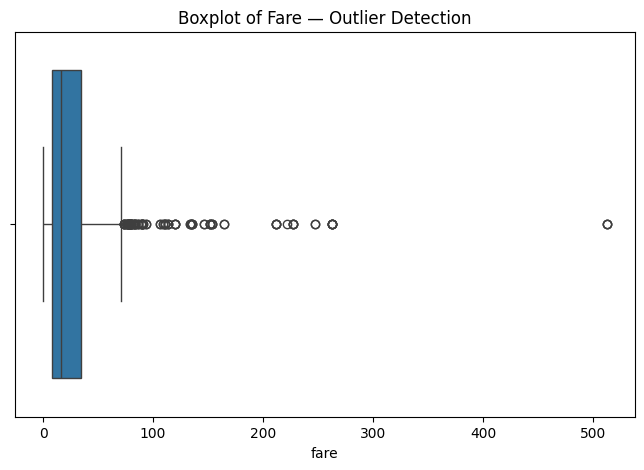

In [ ]:
# --- IQR method ---
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_clean[(df_clean['fare'] < lower_bound) | (df_clean['fare'] > upper_bound)]
print('Outliers detected using IQR method:', outliers_iqr.shape[0])

# --- Z-score method ---
z_scores = np.abs(stats.zscore(df_clean['fare']))
outliers_z = df_clean[z_scores > 3]
print('Outliers detected using Z-score method:', outliers_z.shape[0])

# --- Visualization ---
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean['fare'])
plt.title('Boxplot of Fare — Outlier Detection')
plt.show()

## 7. Handle Outliers (Capping / Winsorization)

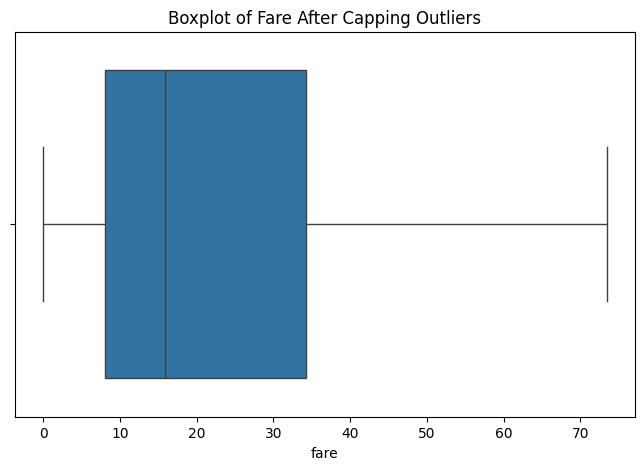

In [ ]:
# Cap values beyond the IQR bounds instead of deleting rows (preserves sample size)
df_clean['fare'] = np.where(df_clean['fare'] > upper_bound, upper_bound,
                     np.where(df_clean['fare'] < lower_bound, lower_bound, df_clean['fare']))

plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean['fare'])
plt.title('Boxplot of Fare After Capping Outliers')
plt.show()

## 8. Categorical Encoding — Label Encoding & One-Hot Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

# --- Label Encoding (for binary / ordinal-like categorical column) ---
le = LabelEncoder()
df_clean['sex_encoded'] = le.fit_transform(df_clean['sex'])
print('Label mapping for sex:', dict(zip(le.classes_, le.transform(le.classes_))))

# --- One-Hot Encoding (for nominal categorical columns) ---
df_encoded = pd.get_dummies(df_clean, columns=['embarked', 'class'],
                             prefix=['embarked', 'class'])

display(df_encoded.head())

Label mapping for sex: {'female': np.int64(0), 'male': np.int64(1)}


,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alive,alone,sex_encoded,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,no,False,1,False,False,True,False,False,True
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,yes,False,0,True,False,False,True,False,False
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,yes,True,0,False,False,True,False,False,True
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,yes,False,0,False,False,True,True,False,False
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,no,True,1,False,False,True,False,False,True


## 9. Feature Scaling — Min-Max Normalization & Standardization

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max Normalization -> scales values into [0, 1]
minmax_scaler = MinMaxScaler()
df_encoded['fare_minmax'] = minmax_scaler.fit_transform(df_encoded[['fare']])

# Standardization (Z-score scaling) -> mean 0, std 1
standard_scaler = StandardScaler()
df_encoded['age_standard'] = standard_scaler.fit_transform(df_encoded[['age']])

display(df_encoded[['fare', 'fare_minmax', 'age', 'age_standard']].head())

,fare,fare_minmax,age,age_standard
0,7.2500,0.098747,22.0,-0.551060
1,71.2833,0.970901,38.0,0.611945
2,7.9250,0.107941,26.0,-0.260308
3,53.1000,0.723239,35.0,0.393881
4,8.0500,0.109644,35.0,0.393881


## 10. Feature Selection via Correlation Analysis

In [ ]:
numeric_df = df_encoded.select_dtypes(include=[np.number])

correlation_with_target = numeric_df.corr()['survived'].sort_values(ascending=False)
print('Correlation of each numeric feature with target (survived):')
print(correlation_with_target)

# Example: keep only features with |correlation| above a threshold
selected_features = correlation_with_target[abs(correlation_with_target) > 0.1].index.tolist()
print('\nSelected relevant features:', selected_features)

Correlation of each numeric feature with target (survived):
survived        1.000000
fare_minmax     0.306633
fare            0.306633
parch           0.069864
sibsp          -0.037841
age            -0.078114
age_standard   -0.078114
pclass         -0.331388
sex_encoded    -0.516121
Name: survived, dtype: float64

Selected relevant features: ['survived', 'fare_minmax', 'fare', 'pclass', 'sex_encoded']


## 11. Correlation Matrix and Heatmap

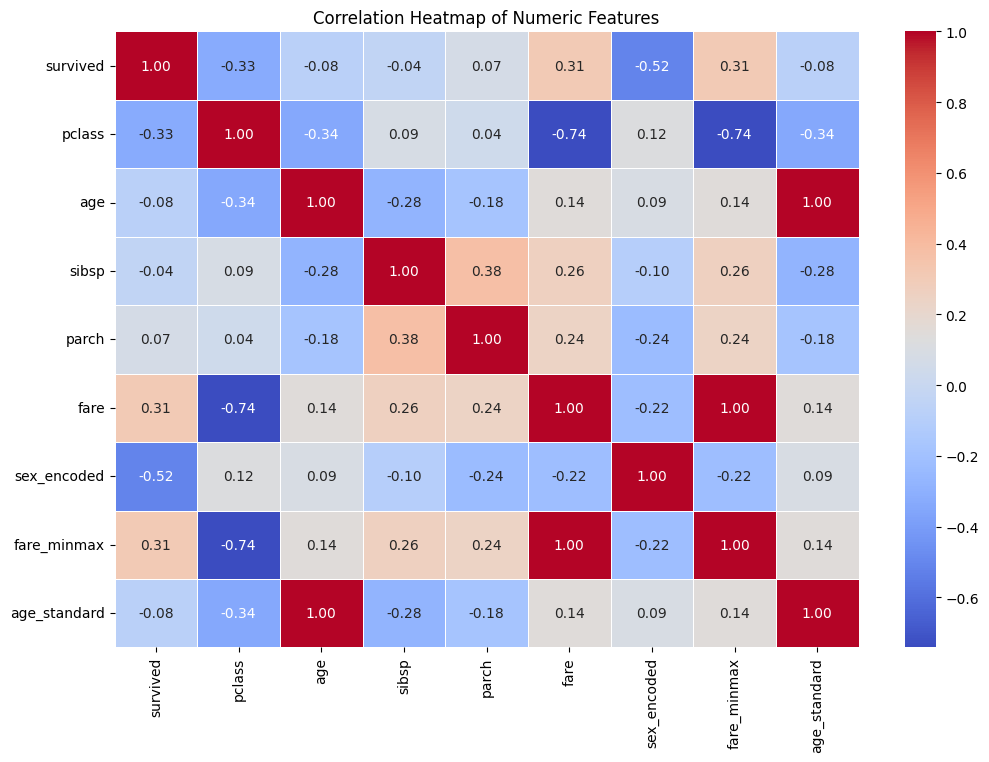

In [ ]:
plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# Interpretation: values close to +1/-1 indicate strong linear relationships;
# values near 0 indicate little to no linear relationship between the two features.

## 12. Feature Engineering — Creating New Features

In [ ]:
# Combine siblings/spouses + parents/children + self -> family size
df_encoded['family_size'] = df_encoded['sibsp'] + df_encoded['parch'] + 1

# Flag passengers traveling alone
df_encoded['is_alone'] = (df_encoded['family_size'] == 1).astype(int)

# Normalize fare by family size to get a per-person cost
df_encoded['fare_per_person'] = df_encoded['fare'] / df_encoded['family_size']

display(df_encoded[['family_size', 'is_alone', 'fare_per_person']].head())

,family_size,is_alone,fare_per_person
0,2,0,3.62500
1,2,0,35.64165
2,1,1,7.92500
3,2,0,26.55000
4,1,1,8.05000


## 13. Data Type Conversion

In [ ]:
# Example numeric -> string (categorical class code)
df_encoded['pclass'] = df_encoded['pclass'].astype(str)

# Ensure numeric columns use correct float dtype
df_encoded['fare'] = df_encoded['fare'].astype(float)
df_encoded['age'] = df_encoded['age'].astype(float)

# Example string -> datetime conversion (adding a simulated date column)
df_encoded['record_date'] = pd.to_datetime('2026-01-01')

print(df_encoded.dtypes)

survived                    int64
pclass                     object
sex                        object
age                       float64
sibsp                       int64
parch                       int64
fare                      float64
who                        object
adult_male                   bool
embark_town                object
alive                      object
alone                        bool
sex_encoded                 int64
embarked_C                   bool
embarked_Q                   bool
embarked_S                   bool
class_First                  bool
class_Second                 bool
class_Third                  bool
fare_minmax               float64
age_standard              float64
family_size                 int64
is_alone                    int64
fare_per_person           float64
record_date        datetime64[ns]
dtype: object


## 14. Handle Inconsistent and Noisy Data

In [ ]:
# Standardize text casing/whitespace
df_encoded['sex'] = df_encoded['sex'].astype(str).str.strip().str.lower()
df_encoded['embark_town'] = df_encoded['embark_town'].astype(str).str.strip().str.title()

# Remove logically impossible values (noise)
before_shape = df_encoded.shape
df_encoded = df_encoded[(df_encoded['age'] >= 0) & (df_encoded['fare'] >= 0)]

print('Shape before removing noisy rows:', before_shape)
print('Shape after removing noisy rows :', df_encoded.shape)

Shape before removing noisy rows: (775, 25)
Shape after removing noisy rows : (775, 25)


## 15. Train-Test Split using Scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split

numeric_df = df_encoded.select_dtypes(include=[np.number]).dropna()
X = numeric_df.drop(columns=['survived'])
y = numeric_df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set shape:', X_train.shape)
print('Testing set shape :', X_test.shape)

Training set shape: (620, 10)
Testing set shape : (155, 10)


## 16. Data Balancing — Random Oversampling / SMOTE

In [ ]:
print('Class distribution BEFORE balancing:')
print(y_train.value_counts())

!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print('\nClass distribution AFTER SMOTE:')
print(y_train_balanced.value_counts())

Class distribution BEFORE balancing:
survived
0    364
1    256
Name: count, dtype: int64

Class distribution AFTER SMOTE:
survived
1    364
0    364
Name: count, dtype: int64


## 17. Visualize Distribution Before and After Preprocessing

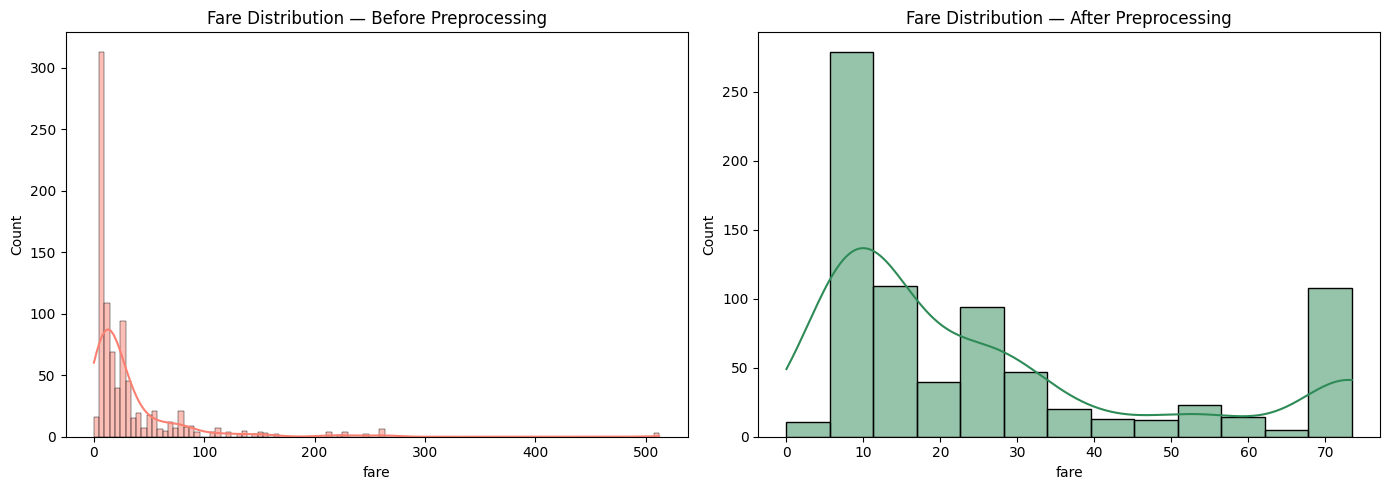

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['fare'].dropna(), kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Fare Distribution — Before Preprocessing')

sns.histplot(df_encoded['fare'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Fare Distribution — After Preprocessing')

plt.tight_layout()
plt.show()

## 18. Compare Dataset Before and After Preprocessing

In [ ]:
print('===== BEFORE PREPROCESSING =====')
print('Shape          :', df.shape)
print('Missing values :', df.isnull().sum().sum())
print('Duplicate rows :', df.duplicated().sum())

print('\n===== AFTER PREPROCESSING =====')
print('Shape          :', df_encoded.shape)
print('Missing values :', df_encoded.isnull().sum().sum())
print('Duplicate rows :', df_encoded.duplicated().sum())

print('\nSummary of changes made:')
print('- Missing values imputed (median/mode) and one high-missing column dropped')
print('- Duplicate rows removed')
print('- Outliers in fare capped using the IQR method')
print('- Categorical variables encoded (Label + One-Hot)')
print('- Numeric features scaled (Min-Max and Standardization)')
print('- New engineered features added (family_size, is_alone, fare_per_person)')
print('- Data types corrected/converted where needed')

===== BEFORE PREPROCESSING =====
Shape          : (891, 15)
Missing values : 869
Duplicate rows : 107

===== AFTER PREPROCESSING =====
Shape          : (775, 25)
Missing values : 0
Duplicate rows : 6

Summary of changes made:
- Missing values imputed (median/mode) and one high-missing column dropped
- Duplicate rows removed
- Outliers in fare capped using the IQR method
- Categorical variables encoded (Label + One-Hot)
- Numeric features scaled (Min-Max and Standardization)
- New engineered features added (family_size, is_alone, fare_per_person)
- Data types corrected/converted where needed


## 19. Save the Cleaned and Preprocessed Dataset

In [ ]:
df_encoded.to_csv('cleaned_titanic_dataset.csv', index=False)
print("Cleaned dataset saved as 'cleaned_titanic_dataset.csv'")

# Download the file to your local machine (Colab only)
from google.colab import files
files.download('cleaned_titanic_dataset.csv')

Cleaned dataset saved as 'cleaned_titanic_dataset.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 20. Documentation Summary & Pushing the Notebook to GitHub

**Preprocessing steps performed in this notebook, in order:**

1. Loaded the Titanic dataset with Pandas and reviewed its structure.
2. Inspected row/column counts, data types, and missing-value counts.
3. Explored the data via `head()`, `tail()`, and `sample()`.
4. Imputed missing values (median for numeric, mode for categorical) and dropped a high-missing column.
5. Detected and removed duplicate rows.
6. Detected outliers in `fare` using the IQR and Z-score methods, visualized with a boxplot.
7. Handled outliers by capping them at the IQR bounds.
8. Encoded categorical variables using Label Encoding and One-Hot Encoding.
9. Scaled numeric features with Min-Max Normalization and Standardization.
10. Selected relevant features using correlation with the target variable.
11. Generated a correlation matrix and heatmap to interpret feature relationships.
12. Engineered new features: `family_size`, `is_alone`, `fare_per_person`.
13. Converted data types (e.g., string ↔ numeric, added a datetime column).
14. Cleaned inconsistent/noisy text data and removed logically invalid rows.
15. Split the data into training and testing sets with `train_test_split`.
16. Balanced the training set using SMOTE.
17. Visualized the `fare` distribution before and after preprocessing.
18. Compared before/after statistics and summarized all changes.
19. Saved the final cleaned dataset as `cleaned_titanic_dataset.csv`.
20. Documented every step above with explanations and outputs.

**Pushing this notebook to GitHub** (run in a Colab cell, replace the placeholders):

In [ ]:
!git init
!git add .
!git commit -m 'Data preprocessing pipeline - Titanic dataset'
!git branch -M main
!git remote add origin https://github.com/devangc006/Ai-ML.git
!git push -u origin main

Reinitialized existing Git repository in /content/.git/
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@a4f605750ba9.(none)')
/bin/bash: line 1: your-repo: No such file or directory
error: src refspec main does not match any
error: failed to push some refs to 'origin'
